### Bước 2.0: Setup + tải dataset "Garbage Classification (12 classes)"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil, hashlib
from google.colab import userdata

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

PROJECT_ROOT = "/content/drive/MyDrive/waste-classification"
DATA_RAW_DIR = os.path.join(PROJECT_ROOT, "data/raw")
DATA_CLASS_DIR = os.path.join(DATA_RAW_DIR, "dataset-resized")   # TrashNet gốc
CLASS_NAMES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

!pip install -q kaggle

# Xóa file zip cũ (tránh lỗi "resume" chồng dữ liệu từ lần tải trước)
!rm -f garbage-classification.zip

new_dataset_root = os.path.join(DATA_RAW_DIR, "garbage_12class")

# Xóa sạch thư mục đã giải nén cũ (nếu có) -> đảm bảo lần giải nén này "sạch" 100%,
# không còn sót file rác/file lỗi từ lần chạy dở dang trước
if os.path.exists(new_dataset_root):
    shutil.rmtree(new_dataset_root)
    print(f"Đã xóa thư mục cũ: {new_dataset_root}")

!kaggle datasets download -d mostafaabla/garbage-classification -o
!ls -lh garbage-classification.zip   # kiểm tra dung lượng phải ~239-240MB

# -o : tự động OVERWRITE mọi file trùng, không hỏi y/n/A/N nữa (tương đương gõ "A" cho mọi file)
# -q : chạy im lặng, không in ra từng file (dataset nhiều file, in hết sẽ rất dài)
!unzip -q -o garbage-classification.zip -d {new_dataset_root}

# In cấu trúc để xác nhận đường dẫn thật
for root, dirs, files in os.walk(new_dataset_root):
    level = root.replace(new_dataset_root, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/  ({len(files)} files)" if files else f"{indent}{os.path.basename(root)}/")
    if level > 2:
        continue

Mounted at /content/drive
Dataset URL: https://www.kaggle.com/datasets/mostafaabla/garbage-classification
License(s): ODbL-1.0
100% 239M/239M [00:02<00:00, 110MB/s]

-rw-r--r-- 1 root root 240M Jan 24  2021 garbage-classification.zip
garbage_12class/
  garbage_classification/
    battery/  (945 files)
    biological/  (985 files)
    brown-glass/  (607 files)
    cardboard/  (891 files)
    clothes/  (5325 files)
    green-glass/  (629 files)
    metal/  (769 files)
    paper/  (1050 files)
    plastic/  (865 files)
    shoes/  (1977 files)
    trash/  (697 files)
    white-glass/  (775 files)


### Bước 2.1: Đường dẫn thực tế + mapping 12 class → 6 class

In [ ]:
# Đường dẫn ĐÚNG theo cấu trúc thực tế (có thêm 1 lớp thư mục con lồng bên trong)
new_dataset_path = os.path.join(DATA_RAW_DIR, "garbage_12class", "garbage_classification")

# Chỉ lấy 6 class khớp với TrashNet, bỏ qua battery/biological/clothes/shoes
# -> giữ đúng phạm vi đồ án ban đầu (đã thống nhất chọn hướng 6 class)
CLASS_MAPPING = {
    'cardboard': ['cardboard'],
    'glass': ['brown-glass', 'green-glass', 'white-glass'],   # gộp 3 màu glass thành 1 class
    'metal': ['metal'],
    'paper': ['paper'],
    'plastic': ['plastic'],
    'trash': ['trash']
}

### Bước 2.2: Hàm phát hiện ảnh trùng lặp bằng hash MD5

In [ ]:
def hash_anh(duong_dan):
    """Tính hash MD5 nội dung file ảnh - dùng để phát hiện ảnh giống hệt nhau (trùng byte-for-byte)"""
    with open(duong_dan, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

def lay_hash_toan_bo_anh(thu_muc):
    """Trả về set các hash của toàn bộ ảnh trong 1 thư mục (dùng để tra cứu trùng lặp nhanh)"""
    hash_set = set()
    for f in os.listdir(thu_muc):
        path = os.path.join(thu_muc, f)
        if os.path.isfile(path):
            hash_set.add(hash_anh(path))
    return hash_set

### Bước 2.3: Gộp dữ liệu — copy TrashNet gốc + ảnh mới không trùng vào thư mục gộp

In [ ]:
DATA_COMBINED_DIR = os.path.join(PROJECT_ROOT, "data/raw_combined")
os.makedirs(DATA_COMBINED_DIR, exist_ok=True)

thong_ke_gop = {}

for class_name in CLASS_NAMES:
    dich_folder = os.path.join(DATA_COMBINED_DIR, class_name)
    os.makedirs(dich_folder, exist_ok=True)

    # 1. Copy toàn bộ ảnh TrashNet gốc vào trước, thêm tiền tố để tránh trùng TÊN file
    goc_folder = os.path.join(DATA_CLASS_DIR, class_name)
    for f in os.listdir(goc_folder):
        shutil.copy(os.path.join(goc_folder, f), os.path.join(dich_folder, f"trashnet_{f}"))

    # 2. Tính hash của các ảnh đã copy để chuẩn bị check trùng NỘI DUNG
    hash_da_co = lay_hash_toan_bo_anh(dich_folder)

    # 3. Duyệt các folder nguồn (theo mapping), chỉ copy ảnh có hash CHƯA từng gặp
    so_anh_them = 0
    so_anh_trung = 0
    for subfolder_name in CLASS_MAPPING[class_name]:
        subfolder_path = os.path.join(new_dataset_path, subfolder_name)
        if not os.path.exists(subfolder_path):
            print(f"CẢNH BÁO: không tìm thấy folder {subfolder_path}, bỏ qua")
            continue

        for f in os.listdir(subfolder_path):
            src_path = os.path.join(subfolder_path, f)
            if not os.path.isfile(src_path):
                continue
            h = hash_anh(src_path)
            if h in hash_da_co:
                so_anh_trung += 1
                continue
            dst_path = os.path.join(dich_folder, f"new_{subfolder_name}_{f}")
            shutil.copy(src_path, dst_path)
            hash_da_co.add(h)
            so_anh_them += 1

    thong_ke_gop[class_name] = {
        'tong_sau_gop': len(os.listdir(dich_folder)),
        'anh_moi_them': so_anh_them,
        'anh_trung_bo_qua': so_anh_trung
    }
    print(f"{class_name}: +{so_anh_them} ảnh mới, bỏ qua {so_anh_trung} ảnh trùng, tổng {thong_ke_gop[class_name]['tong_sau_gop']} ảnh")

print("\nHoàn tất gộp dataset!")
print(thong_ke_gop)

cardboard: +488 ảnh mới, bỏ qua 403 ảnh trùng, tổng 891 ảnh
glass: +1523 ảnh mới, bỏ qua 488 ảnh trùng, tổng 2024 ảnh
metal: +359 ảnh mới, bỏ qua 410 ảnh trùng, tổng 769 ảnh
paper: +456 ảnh mới, bỏ qua 594 ảnh trùng, tổng 1050 ảnh
plastic: +387 ảnh mới, bỏ qua 478 ảnh trùng, tổng 869 ảnh
trash: +697 ảnh mới, bỏ qua 0 ảnh trùng, tổng 834 ảnh

Hoàn tất gộp dataset!
{'cardboard': {'tong_sau_gop': 891, 'anh_moi_them': 488, 'anh_trung_bo_qua': 403}, 'glass': {'tong_sau_gop': 2024, 'anh_moi_them': 1523, 'anh_trung_bo_qua': 488}, 'metal': {'tong_sau_gop': 769, 'anh_moi_them': 359, 'anh_trung_bo_qua': 410}, 'paper': {'tong_sau_gop': 1050, 'anh_moi_them': 456, 'anh_trung_bo_qua': 594}, 'plastic': {'tong_sau_gop': 869, 'anh_moi_them': 387, 'anh_trung_bo_qua': 478}, 'trash': {'tong_sau_gop': 834, 'anh_moi_them': 697, 'anh_trung_bo_qua': 0}}


**Kết quả thực tế đã chạy (lưu lại để đối chiếu, KHÔNG cần chạy lại nếu đã có `data/raw_combined` trên Drive):**

| Class | Ảnh mới thêm | Ảnh trùng bị bỏ qua | Tổng sau gộp |
|---|---|---|---|
| cardboard | 488 | 403 | 891 |
| glass | 1523 | 488 | 2024 |
| metal | 359 | 410 | 769 |
| paper | 456 | 594 | 1050 |
| plastic | 387 | 478 | 869 |
| **trash** | **697** | 0 | **834** |

→ `trash` tăng từ 137 lên 834 ảnh (gấp ~6 lần) — không có ảnh nào bị trùng, xác nhận 697 ảnh trash mới hoàn toàn độc lập với TrashNet gốc.

### Bước 2.4: Trực quan hóa trước/sau gộp

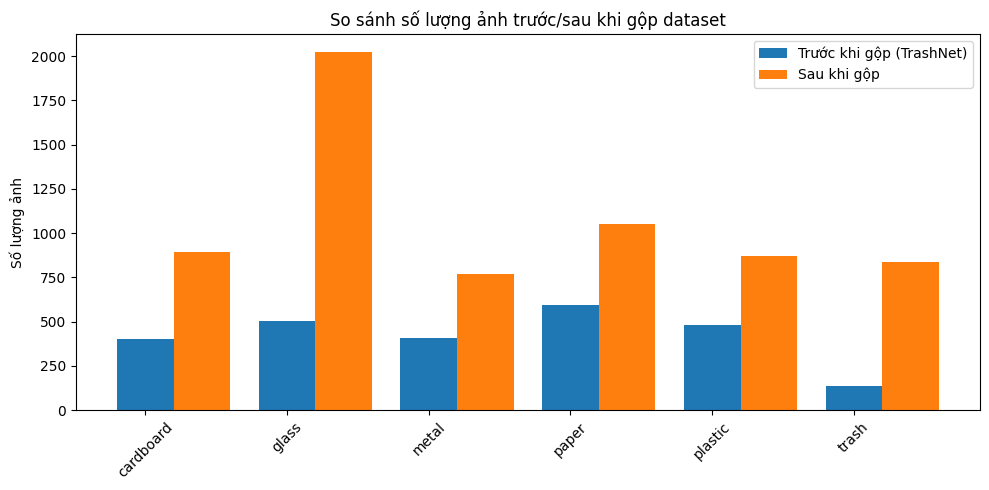

In [ ]:
import matplotlib.pyplot as plt

classes = list(thong_ke_gop.keys())
truoc = [thong_ke_gop[c]['tong_sau_gop'] - thong_ke_gop[c]['anh_moi_them'] for c in classes]
sau = [thong_ke_gop[c]['tong_sau_gop'] for c in classes]

x = range(len(classes))
plt.figure(figsize=(10,5))
plt.bar(x, truoc, width=0.4, label='Trước khi gộp (TrashNet)', align='edge')
plt.bar([i+0.4 for i in x], sau, width=0.4, label='Sau khi gộp', align='edge')
plt.xticks([i+0.2 for i in x], classes, rotation=45)
plt.ylabel("Số lượng ảnh")
plt.title("So sánh số lượng ảnh trước/sau khi gộp dataset")
plt.legend()
plt.tight_layout()
plt.show()

### Bước 2.5: Chia lại train/val/test trên dữ liệu ĐÃ GỘP


In [ ]:
!pip install -q split-folders
import splitfolders

DATA_SPLIT_COMBINED_DIR = os.path.join(PROJECT_ROOT, "data/train_test_split_combined")

splitfolders.ratio(
    DATA_COMBINED_DIR,
    output=DATA_SPLIT_COMBINED_DIR,
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)

for split in ['train', 'val', 'test']:
    print(f"\n{split}:")
    for cls in CLASS_NAMES:
        path = os.path.join(DATA_SPLIT_COMBINED_DIR, split, cls)
        print(f"  {cls}: {len(os.listdir(path))} ảnh")

Copying files: 6437 files [01:38, 65.35 files/s]



train:
  cardboard: 623 ảnh
  glass: 1416 ảnh
  metal: 538 ảnh
  paper: 735 ảnh
  plastic: 608 ảnh
  trash: 583 ảnh

val:
  cardboard: 133 ảnh
  glass: 303 ảnh
  metal: 115 ảnh
  paper: 157 ảnh
  plastic: 130 ảnh
  trash: 125 ảnh

test:
  cardboard: 135 ảnh
  glass: 305 ảnh
  metal: 116 ảnh
  paper: 158 ảnh
  plastic: 131 ảnh
  trash: 126 ảnh


- Dùng thư mục **mới hoàn toàn** (`train_test_split_combined`), KHÔNG ghi đè `train_test_split` cũ — giữ được bản chia dữ liệu gốc để so sánh "trước gộp vs sau gộp" trong báo cáo.
**Kết quả thực tế đã chạy:**

| Split | cardboard | glass | metal | paper | plastic | trash |
|---|---|---|---|---|---|---|
| train | 623 | 1416 | 538 | 735 | 608 | 583 |
| val | 133 | 303 | 115 | 157 | 130 | 125 |
| test | 135 | 305 | 116 | 158 | 131 | 126 |

Tổng 6437 ảnh (so với 2527 ảnh của TrashNet gốc) — dataset đã gộp lớn hơn ~2.5 lần.